In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')  
plt.rcParams['figure.dpi'] = 100

In [2]:
df = pd.read_csv('../data/raw/compas-scores-two-years-violent.csv')
print(f'Dataset shape: {df.shape}')
print('\nColumn types:')
print(df.dtypes)
df.head(5)

Dataset shape: (4743, 54)

Column types:
id                           int64
name                        object
first                       object
last                        object
compas_screening_date       object
sex                         object
dob                         object
age                          int64
age_cat                     object
race                        object
juv_fel_count                int64
decile_score                 int64
juv_misd_count               int64
juv_other_count              int64
priors_count                 int64
days_b_screening_arrest    float64
c_jail_in                   object
c_jail_out                  object
c_case_number               object
c_offense_date              object
c_arrest_date               object
c_days_from_compas         float64
c_charge_degree             object
c_charge_desc               object
is_recid                     int64
r_case_number               object
r_charge_degree             object
r_days_from_ar

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,two_year_recid.1
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1,1
2,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0,0
3,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,Low,2013-03-26,NaN,NaN,2,0,1102,0,0,0
4,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0,0


Target Distribution:
is_violent_recid
0    3924
1     819
Name: count, dtype: int64

Positive rate (reoffended): 17.3%


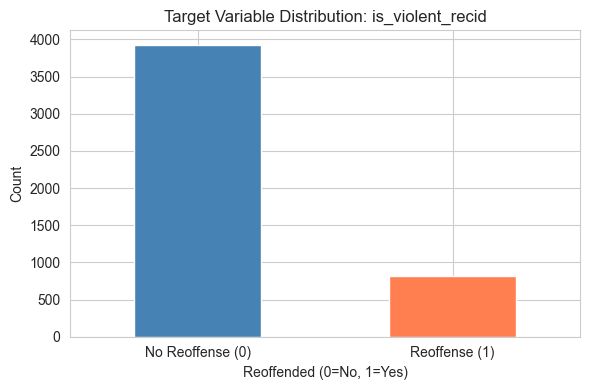

In [3]:
target_counts = df['is_violent_recid'].value_counts()
print('Target Distribution:')
print(target_counts)

positive_rate = target_counts[1] / len(df) * 100
print(f'\nPositive rate (reoffended): {positive_rate:.1f}%')

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target Variable Distribution: is_violent_recid')
ax.set_xlabel('Reoffended (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Reoffense (0)', 'Reoffense (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [4]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
print('Columns with missing values:')
print(missing_df[missing_df['missing_count'] > 0])

Columns with missing values:
                         missing_count  missing_pct
violent_recid                     4743       100.00
r_days_from_arrest                4053        85.45
r_jail_out                        4053        85.45
r_jail_in                         4053        85.45
c_arrest_date                     3983        83.98
vr_charge_degree                  3924        82.73
vr_offense_date                   3924        82.73
vr_charge_desc                    3924        82.73
vr_case_number                    3924        82.73
r_charge_desc                     3771        79.51
r_charge_degree                   3748        79.02
r_case_number                     3748        79.02
r_offense_date                    3748        79.02
c_offense_date                     771        16.26
c_jail_in                          268         5.65
c_jail_out                         268         5.65
days_b_screening_arrest            268         5.65
in_custody                         

It seems that "violent_recivd" has a 100% missing percentage which is odd. Additionally, columns such as "r_days_from_arrest" and "r_jail_out" both have missing percentages of 85.45. The columns with the lowest missing percentages are "score_text" and "c_case_number".

In [5]:
race_analysis = df.groupby('race')['is_violent_recid'].agg(
    count='count',
    reoffense_rate='mean',
    total_reoffended='sum'
).reset_index()

race_analysis = race_analysis.sort_values('reoffense_rate', ascending=False)
race_analysis['reoffense_rate'] = race_analysis['reoffense_rate'].round(3)
print(race_analysis)

df['compas_high_risk'] = (df['v_decile_score'] >= 5).astype(int)

def false_positive_rate(group):
    did_not_reoffend = group[group['is_violent_recid'] == 0]
    if len(did_not_reoffend) == 0:
        return 0
    return did_not_reoffend['compas_high_risk'].mean()

fpr_by_race = df.groupby('race').apply(false_positive_rate).sort_values(ascending=False)
print('\nCOMPAS False Positive Rate by Race (flagged high-risk but did not reoffend):')
print(fpr_by_race.round(3))

               race  count  reoffense_rate  total_reoffended
4   Native American     11           0.364                 4
0  African-American   2266           0.218               495
1             Asian     27           0.148                 4
5             Other    280           0.136                38
2         Caucasian   1701           0.131               222
3          Hispanic    458           0.122                56

COMPAS False Positive Rate by Race (flagged high-risk but did not reoffend):
race
African-American    0.327
Hispanic            0.179
Caucasian           0.153
Other               0.153
Asian               0.043
Native American     0.000
dtype: float64


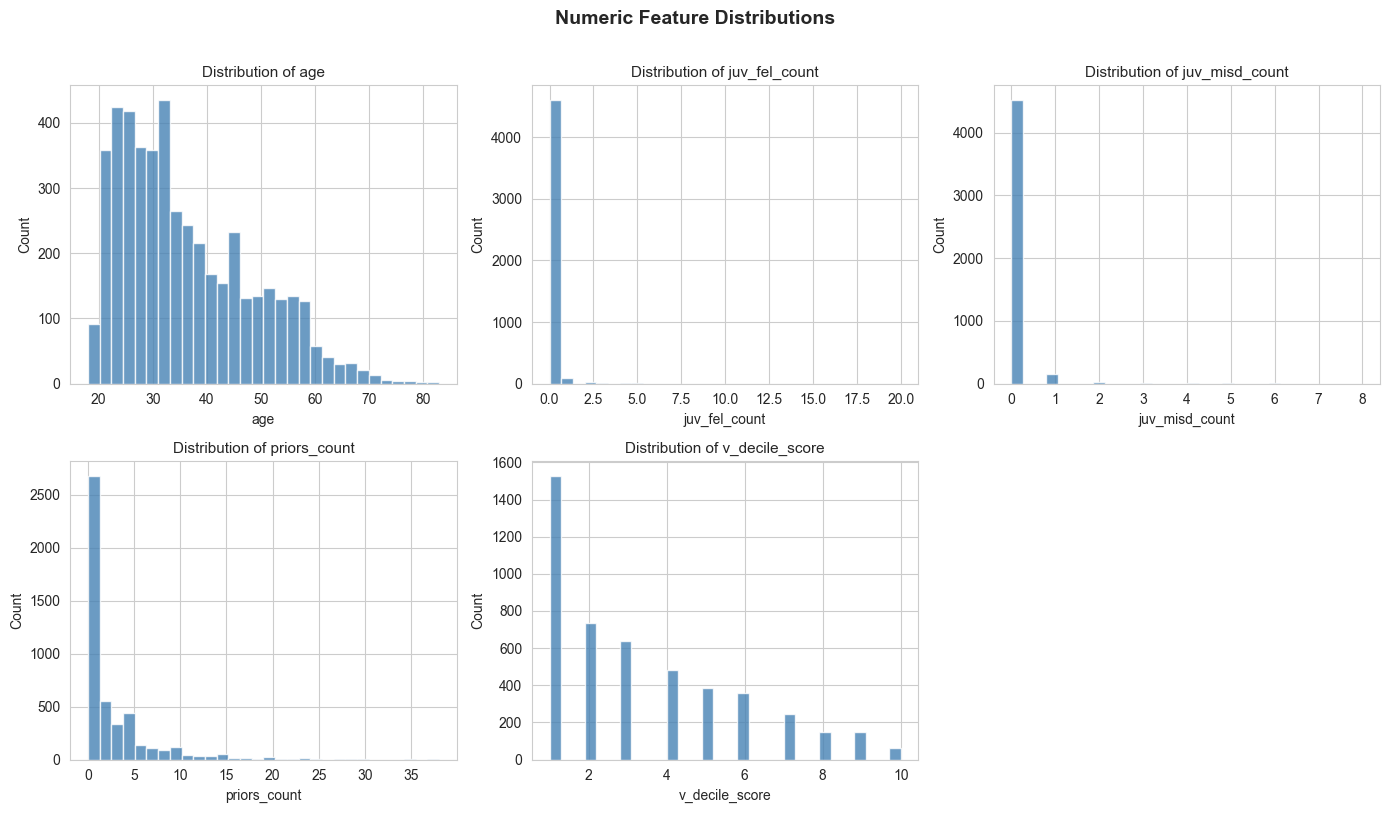

In [6]:
numeric_cols = ['age', 'juv_fel_count', 'juv_misd_count', 'priors_count', 'v_decile_score']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

axes[5].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

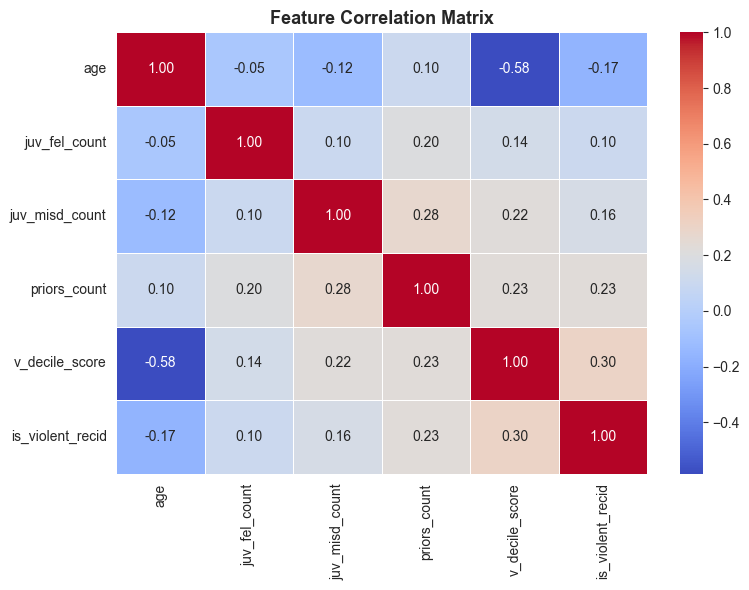

In [7]:
corr_cols = ['age', 'juv_fel_count', 'juv_misd_count', 'priors_count', 'v_decile_score', 'is_violent_recid']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/correlation_matrix.png', dpi=150)
plt.show()

No single feature correlates with "is_violent_recid" in a way such that |r| >= 0.8, but "age" has a correlation of -0.17 and "priors_count" has a correlation of 0.23. "v_decile_score" has a correlation of 0.30, but that is probably also correlated with the other predictive features.